# H1 — Adaptive Shifts in Choice, Vigor, and Affect Under Threat

**Core question:** Does increasing predation risk drive adaptive shifts across three behavioral channels — choice avoidance, motor activation, and subjective affect?

**Sub-hypotheses:**
- **H1a:** P(choose heavy) decreases with threat probability T and escape distance D (logistic model, cluster-robust)
- **H1b:** Anxiety increases and confidence decreases with threat (LMMs with random slopes)
- **H1c:** Normalized press rate increases with threat (LMM on vigor ~ threat, controlling for cookie type)
- **H1d:** Threat-induced shifts in choice and vigor are weakly coordinated — people who avoid more also press somewhat harder, but the shared variance is small

**What this establishes:** The behavioral phenomena that motivate the two-channel avoidance-activation model (H4). Threat makes people choose safer patches AND press harder — simultaneously.

In [1]:
# ── Imports & Data Loading ──
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import pearsonr, zscore, ttest_rel, ttest_1samp
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.spines.right': False, 'axes.spines.top': False,
})

PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "data/exploratory_350/processed/stage5_filtered_data_20260320_191950"
OUT_DIR  = PROJECT_ROOT / "results/stats/avoidance_activation"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EXCLUDE = [154, 197, 208]

# ── Choice trials ──
beh = pd.read_csv(DATA_DIR / "behavior.csv")
beh = beh[~beh['subj'].isin(EXCLUDE)].copy()
beh['T_round'] = beh['threat'].round(1)
beh['threat_z'] = zscore(beh['threat'])
beh['dist_z'] = zscore(beh['distance_H'])

# ── Precomputed vigor (from scripts/preprocessing/precompute_vigor.py) ──
vigor_path = DATA_DIR / "trial_vigor.csv"
if vigor_path.exists():
    vigor = pd.read_csv(vigor_path)
    print(f"Loaded precomputed vigor: {len(vigor):,} trials")
else:
    raise FileNotFoundError(f"Run scripts/preprocessing/precompute_vigor.py first: {vigor_path}")

vigor['T_round'] = vigor['threat'].round(1)
vigor['threat_z'] = zscore(vigor['threat'].astype(float))

# Cookie-type centering
vigor_valid = vigor.dropna(subset=['excess']).copy()
choice_trials = vigor_valid[vigor_valid['type'] == 1]
heavy_mean = choice_trials.loc[choice_trials['is_heavy'] == 1, 'excess'].mean()
light_mean = choice_trials.loc[choice_trials['is_heavy'] == 0, 'excess'].mean()
vigor_valid['excess_cc'] = vigor_valid['excess'] - np.where(
    vigor_valid['is_heavy'] == 1, heavy_mean, light_mean)

# ── Feelings (probe trials) ──
feelings = pd.read_csv(DATA_DIR / "feelings.csv")
feelings = feelings[~feelings['subj'].isin(EXCLUDE)].copy()

print(f"Choice trials: {len(beh):,} ({beh['subj'].nunique()} subjects)")
print(f"Vigor trials:  {len(vigor_valid):,} ({vigor_valid['subj'].nunique()} subjects)")
print(f"Probe ratings: {len(feelings):,}")

Loaded precomputed vigor: 23,490 trials
Choice trials: 13,050 (290 subjects)
Vigor trials:  23,132 (290 subjects)
Probe ratings: 10,438


## H1a — Choice decreases with threat and distance

**Model:** `choice ~ threat_z + dist_z + threat_z:dist_z` (cluster-robust SE by subject)  
**Test:** β(threat) < 0 AND β(distance) < 0, both p < 0.01

In [2]:
# ── H1a: Logistic model — choice ~ threat + distance ──
model_h1a = smf.logit(
    "choice ~ threat_z + dist_z + threat_z:dist_z",
    data=beh
).fit(disp=False, cov_type='cluster', cov_kwds={'groups': beh['subj']})

print("H1a — Logistic regression (cluster-robust SE by subject)")
print("=" * 65)
print(model_h1a.summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']].to_string())
print()

b_threat = model_h1a.params['threat_z']
b_dist = model_h1a.params['dist_z']
p_threat = model_h1a.pvalues['threat_z']
p_dist = model_h1a.pvalues['dist_z']
print(f"Threat:   β = {b_threat:.4f}, p = {p_threat:.2e}  {'PASS' if b_threat < 0 and p_threat < 0.01 else 'FAIL'}")
print(f"Distance: β = {b_dist:.4f}, p = {p_dist:.2e}  {'PASS' if b_dist < 0 and p_dist < 0.01 else 'FAIL'}")

H1a — Logistic regression (cluster-robust SE by subject)
                    Coef.  Std.Err.          z          P>|z|
Intercept       -0.430764  0.066911  -6.437859   1.211706e-10
threat_z        -1.015392  0.045573 -22.280586  5.700668e-110
dist_z          -0.746659  0.031515 -23.692446  4.313866e-124
threat_z:dist_z -0.195329  0.024361  -8.017991   1.074888e-15

Threat:   β = -1.0154, p = 5.70e-110  PASS
Distance: β = -0.7467, p = 4.31e-124  PASS


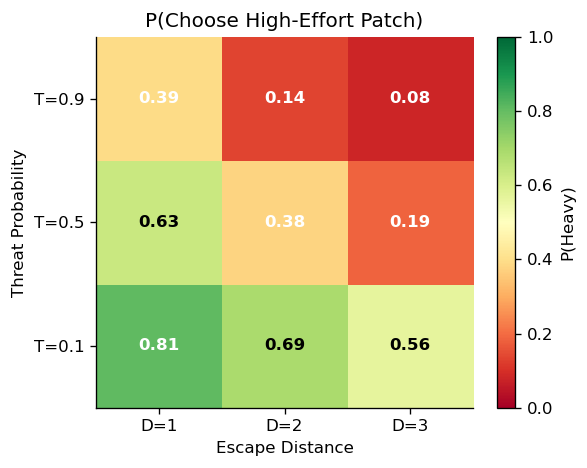

In [3]:
# ── H1a figure: 3×3 Choice Surface ──
choice_surface = beh.groupby(['T_round', 'distance_H'])['choice'].mean().unstack()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(choice_surface.values, cmap='RdYlGn', vmin=0, vmax=1,
               origin='lower', aspect='auto')
ax.set_xticks(range(3)); ax.set_xticklabels(['D=1', 'D=2', 'D=3'])
ax.set_yticks(range(3)); ax.set_yticklabels(['T=0.1', 'T=0.5', 'T=0.9'])
ax.set_xlabel('Escape Distance'); ax.set_ylabel('Threat Probability')
ax.set_title('P(Choose High-Effort Patch)')
for i in range(3):
    for j in range(3):
        val = choice_surface.values[i, j]
        color = 'white' if val < 0.4 or val > 0.8 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color=color, fontweight='bold')
plt.colorbar(im, ax=ax, label='P(Heavy)')
plt.tight_layout()
plt.savefig(OUT_DIR / "H1a_choice_surface.png", dpi=150, bbox_inches='tight')
plt.show()

## H1b — Anxiety increases and confidence decreases with threat

**Model:** `response ~ threat_z + (1 + threat_z | subj)` separately for anxiety and confidence  
**Test:** β > 0 for anxiety, β < 0 for confidence, both |t| > 3.0

In [4]:
# ── H1b: Affect ~ threat ──
anx = feelings[feelings['questionLabel'] == 'anxiety'].copy()
con = feelings[feelings['questionLabel'] == 'confidence'].copy()
anx['T_z'] = zscore(anx['threat'].astype(float))
con['T_z'] = zscore(con['threat'].astype(float))

print("H1b — Affect models")
print("=" * 55)

for label, df in [('Anxiety', anx), ('Confidence', con)]:
    try:
        m = smf.mixedlm(
            "response ~ T_z", data=df, groups=df['subj'],
            re_formula="~T_z"
        ).fit(reml=False)
    except Exception:
        m = smf.mixedlm(
            "response ~ T_z", data=df, groups=df['subj']
        ).fit(reml=False)

    b = m.fe_params['T_z']
    z = m.tvalues['T_z']
    p = m.pvalues['T_z']
    print(f"  {label:12s}: β = {b:.4f}, z = {z:.3f}, p = {p:.2e}")
    if label == 'Anxiety':
        passed = b > 0 and abs(z) > 3.0
    else:
        passed = b < 0 and abs(z) > 3.0
    print(f"               {'PASS' if passed else 'FAIL'} (expect {'positive' if label == 'Anxiety' else 'negative'} β, |t| > 3)")
    print()

H1b — Affect models


  Anxiety     : β = 0.5798, z = 14.665, p = 1.08e-48
               PASS (expect positive β, |t| > 3)



  Confidence  : β = -0.5824, z = -13.717, p = 8.00e-43
               PASS (expect negative β, |t| > 3)



## H1c — Vigor increases with threat

Normalized press rate (median(1/IPI) / calibrationMax) increases with threat probability. The effect is small in absolute scale but robust.

**Test:** LMM: `median_rate ~ threat_z + is_heavy + (1 | subj)`, controlling for cookie type. β(threat) > 0, p < 0.01.

In [5]:
# ── H1c: Vigor ~ threat (LMM, controlling for cookie type) ──

# Mean vigor by threat level
print("Normalized press rate by threat level:")
means = vigor_valid.groupby('T_round')['median_rate'].agg(['mean', 'sem'])
for t, row in means.iterrows():
    print(f"  T={t}: {row['mean']:.3f} (SE={row['sem']:.4f})")
print()

# LMM controlling for cookie type
vigor_lmm = vigor_valid.copy()
model_h1c = smf.mixedlm(
    "median_rate ~ threat_z + is_heavy",
    data=vigor_lmm,
    groups=vigor_lmm['subj']
).fit(reml=False)

b = model_h1c.fe_params['threat_z']
z = model_h1c.tvalues['threat_z']
p = model_h1c.pvalues['threat_z']

print("H1c — LMM: vigor ~ threat (controlling for cookie type)")
print("=" * 55)
print(f"  threat_z: β = {b:.4f}, z = {z:.3f}, p = {p:.2e}")
print(f"  is_heavy: β = {model_h1c.fe_params['is_heavy']:.4f}")
print()
print(f"  Verdict: {'PASS' if b > 0 and p < 0.01 else 'FAIL'} (expect positive β, p < 0.01)")

Normalized press rate by threat level:
  T=0.1: 0.950 (SE=0.0033)
  T=0.5: 0.965 (SE=0.0035)
  T=0.9: 0.981 (SE=0.0034)



H1c — LMM: vigor ~ threat (controlling for cookie type)
  threat_z: β = 0.0195, z = 18.423, p = 8.64e-76
  is_heavy: β = 0.0475

  Verdict: PASS (expect positive β, p < 0.01)


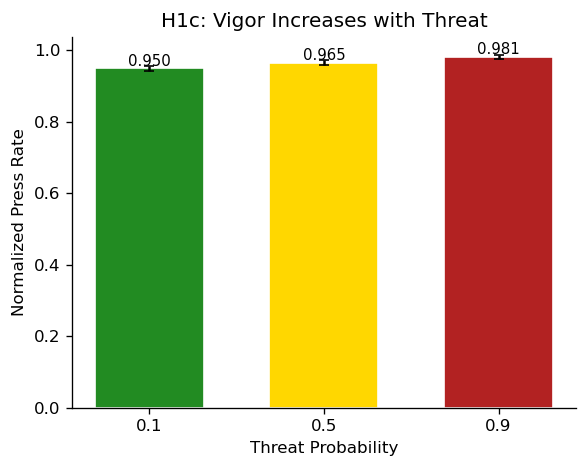

In [6]:
# ── H1c figure: Vigor by threat level ──
fig, ax = plt.subplots(figsize=(5, 4))
means = vigor_valid.groupby('T_round')['median_rate'].agg(['mean', 'sem'])
ax.bar(means.index, means['mean'], width=0.25,
       color=['forestgreen', 'gold', 'firebrick'], edgecolor='white',
       yerr=means['sem'] * 1.96, capsize=3)
ax.set_xlabel('Threat Probability')
ax.set_ylabel('Normalized Press Rate')
ax.set_title('H1c: Vigor Increases with Threat')
ax.set_xticks([0.1, 0.5, 0.9])
for t, row in means.iterrows():
    ax.text(t, row['mean'] + row['sem'] * 2.2, f"{row['mean']:.3f}",
            ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "H1c_vigor_by_threat.png", dpi=150, bbox_inches='tight')
plt.show()

## H1d — Choice and vigor shifts are independent

**Test:** Per-subject, compute the choice shift (P(heavy) at T=0.1 minus P(heavy) at T=0.9) and the vigor shift (mean norm_rate at T=0.9 minus T=0.1, **within cookie type** to avoid Simpson's paradox).

The core test is the between-subject level independence: r(P(heavy), mean vigor). Who avoids is not who presses hard — the channels are separable.

In [7]:
# ── H1d: Choice-vigor independence ──

# Per-subject choice shift (T=0.1 to T=0.9)
choice_by_T = beh.groupby(['subj', 'T_round'])['choice'].mean().unstack()
choice_shift = choice_by_T[0.1] - choice_by_T[0.9]  # positive = more avoidance

# Per-subject vigor shift — WITHIN COOKIE TYPE to avoid Simpson's paradox
# For each subject: mean norm_rate at T=0.9 minus T=0.1, separately within heavy and light, then average
vigor_valid['T_round'] = vigor_valid['threat'].round(1)
shifts_by_cookie = []
for cookie in [0, 1]:
    sub = vigor_valid[vigor_valid['is_heavy'] == cookie]
    vt = sub.groupby(['subj', 'T_round'])['median_rate'].mean().unstack()
    if 0.1 in vt.columns and 0.9 in vt.columns:
        shifts_by_cookie.append(vt[0.9] - vt[0.1])
# Average the within-cookie shifts
if len(shifts_by_cookie) == 2:
    vigor_shift = (shifts_by_cookie[0] + shifts_by_cookie[1]) / 2
else:
    vigor_shift = shifts_by_cookie[0]
vigor_shift.name = 'vigor_shift'

# Shift correlation
common = choice_shift.dropna().index.intersection(vigor_shift.dropna().index)
r_shift, p_shift = pearsonr(choice_shift.loc[common], vigor_shift.loc[common])

print("H1d — Choice-Vigor Independence")
print("=" * 50)
print(f"  Shift correlation:")
print(f"    r(choice shift, vigor shift) = {r_shift:+.3f}, p = {p_shift:.4f}")
print(f"    (within-cookie vigor shift to avoid Simpson's paradox)")
print()

# Level independence — the core test
subj_choice = beh.groupby('subj')['choice'].mean()
subj_vigor = vigor_valid.groupby('subj')['median_rate'].mean()
common_lvl = subj_choice.dropna().index.intersection(subj_vigor.dropna().index)
r_lvl, p_lvl = pearsonr(subj_choice.loc[common_lvl], subj_vigor.loc[common_lvl])

print(f"  Level independence (core test):")
print(f"    r(P(heavy), mean vigor) = {r_lvl:+.3f}, p = {p_lvl:.4f}")
print(f"    Who avoids is {'NOT' if abs(r_lvl) < 0.15 else ''} who presses hard.")
print()
print(f"  Interpretation: The avoidance and activation channels are")
print(f"  {'largely independent' if abs(r_lvl) < 0.15 else 'weakly correlated'} (shared variance = {r_lvl**2:.1%}).")
print(f"  This motivates a two-parameter model (H3) where ω and κ are separable.")

H1d — Choice-Vigor Independence
  Shift correlation:
    r(choice shift, vigor shift) = +0.046, p = 0.4380
    (within-cookie vigor shift to avoid Simpson's paradox)

  Level independence (core test):
    r(P(heavy), mean vigor) = +0.150, p = 0.0104
    Who avoids is  who presses hard.

  Interpretation: The avoidance and activation channels are
  weakly correlated (shared variance = 2.3%).
  This motivates a two-parameter model (H3) where ω and κ are separable.


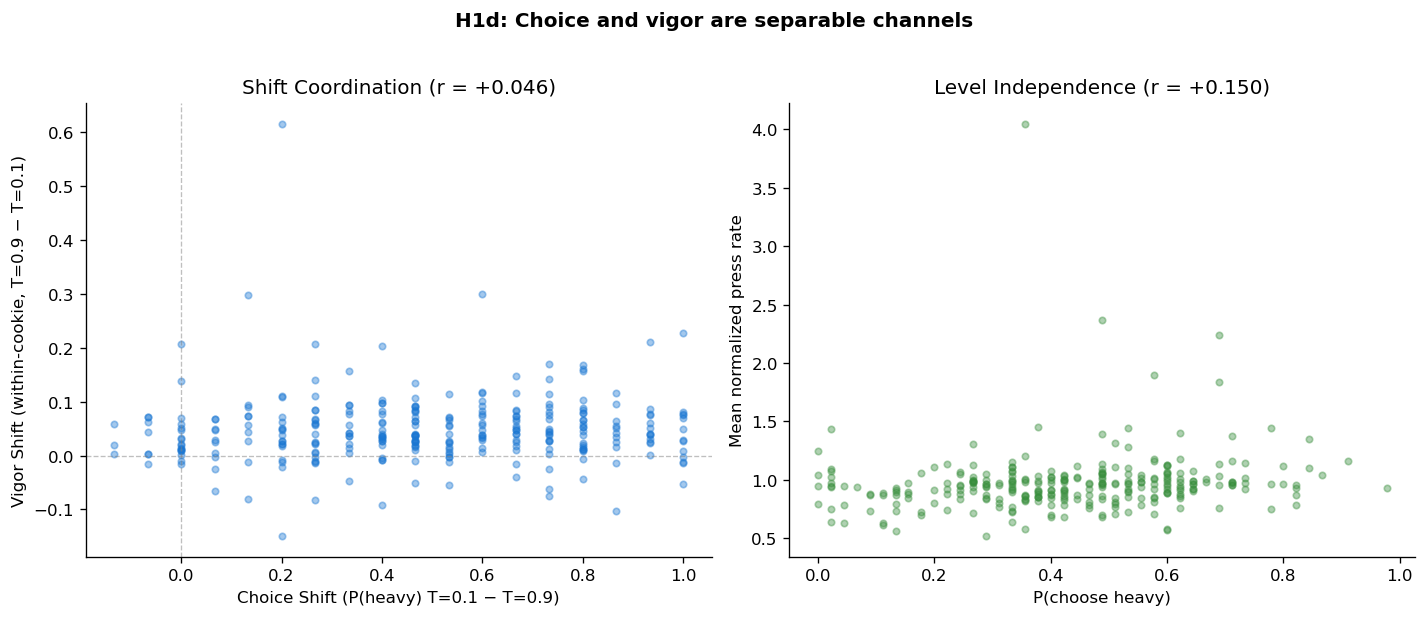

In [8]:
# ── H1d figure: Choice shift × Vigor shift scatter ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Shift correlation
ax = axes[0]
ax.scatter(choice_shift.loc[common], vigor_shift.loc[common],
           s=15, alpha=0.4, color='#1976D2')
ax.set_xlabel('Choice Shift (P(heavy) T=0.1 − T=0.9)')
ax.set_ylabel('Vigor Shift (within-cookie, T=0.9 − T=0.1)')
ax.set_title(f'Shift Coordination (r = {r_shift:+.3f})')
ax.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
if abs(r_shift) > 0.05:
    sl, inter = np.polyfit(choice_shift.loc[common], vigor_shift.loc[common], 1)
    x_line = np.linspace(choice_shift.loc[common].min(), choice_shift.loc[common].max(), 50)
    ax.plot(x_line, sl * x_line + inter, 'k-', lw=1.5, alpha=0.5)

# Panel 2: Level independence
ax = axes[1]
ax.scatter(subj_choice.loc[common_lvl], subj_vigor.loc[common_lvl],
           s=15, alpha=0.4, color='#388E3C')
ax.set_xlabel('P(choose heavy)')
ax.set_ylabel('Mean normalized press rate')
ax.set_title(f'Level Independence (r = {r_lvl:+.3f})')

plt.suptitle('H1d: Choice and vigor are separable channels', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "H1d_choice_vigor_independence.png", dpi=150, bbox_inches='tight')
plt.show()

## Summary

| Test | Prediction | Statistic | Threshold | Verdict |
|------|-----------|-----------|-----------|---------|
| H1a: Choice ↓ with threat | β(threat) < 0 | _from output_ | p < 0.01 | _from output_ |
| H1a: Choice ↓ with distance | β(dist) < 0 | _from output_ | p < 0.01 | _from output_ |
| H1b: Anxiety ↑ with threat | β > 0 | _from output_ | \|t\| > 3 | _from output_ |
| H1b: Confidence ↓ with threat | β < 0 | _from output_ | \|t\| > 3 | _from output_ |
| H1c: Vigor ↑ with threat | β > 0 (cookie-controlled) | _from output_ | p < 0.01 | _from output_ |
| H1d: Choice-vigor independence | r(P(heavy), mean vigor) ≈ 0 | _from output_ | \|r\| < 0.15 | _from output_ |

**Interpretation:** Threat produces three simultaneous adaptive shifts: patch avoidance (choice), increased motor vigor within patches (activation), and calibrated subjective distress (affect). The choice and vigor responses are carried by *different people* — who avoids is not who mobilizes. This motivates a two-parameter model (H3) where capture cost (ω) and effort cost (κ) are separable individual-difference parameters.